# Lab 1: Getting Started
## Explore the Water Potability Dataset

**Dataset:** Water Potability (Kaggle). Each row is one water sample. The columns are nine chemical measurements and one label. The label `Potability` is 1 if the water is safe to drink and 0 if it is not.

**Plan:**
1. Load the data and preview it.
2. Check the structure and summary statistics.
3. Check data quality and fix missing values.
4. Explore distributions, class balance and relationships.

## 1. Load dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/My Drive/water_potability.csv'
df = pd.read_csv(file_path)
# Display the first few rows of the dataframe
print(df.head())

         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


`pd.read_csv()` reads the file into a DataFrame. A DataFrame is a table with named columns. `head()` shows the first five rows, so the file loaded correctly. I can already see `NaN` values in `ph` and `Sulfate`. These are missing measurements.

## 2. Structure and summary statistics

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None
                ph     Hardness        Solids  Chloramines      Sulfate  \
count  2785.000000  3276.000000   3276.000000  3276.000000  2495.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.594320    32.879761   8768.570828     1.583085 

**What I see:**
- The dataset has 3,276 rows and 10 columns. All columns are numeric.
- `ph`, `Sulfate` and `Trihalomethanes` have fewer non-null values than the other columns. They have missing data.
- `ph` has a minimum of 0 and a maximum of 14. These are the extremes of the pH scale, so they are unusual for drinking water. They may be errors or rare samples.
- `Solids` has values in the tens of thousands. Most other features are between 0 and 500. The features are on very different scales. This would matter for many machine learning models.

## 3. Data quality

In [4]:
print("Shape:", df.shape)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Percent missing:")
print((df.isnull().mean() * 100).round(1))
print()
print("Duplicate rows:", df.duplicated().sum())

Shape: (3276, 10)

Missing values per column:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Percent missing:
ph                 15.0
Hardness            0.0
Solids              0.0
Chloramines         0.0
Sulfate            23.8
Conductivity        0.0
Organic_carbon      0.0
Trihalomethanes     4.9
Turbidity           0.0
Potability          0.0
dtype: float64

Duplicate rows: 0


There are no duplicate rows. Three columns have missing values: `ph` (491), `Sulfate` (781) and `Trihalomethanes` (162). `Sulfate` is missing in about 24% of rows. Dropping every row with a missing value would remove a large part of the data. I will fill the gaps instead.

In [5]:
# Fill missing values with the median of each column
df_clean = df.copy()
for col in ['ph', 'Sulfate', 'Trihalomethanes']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after cleaning:", df_clean.isnull().sum().sum())

Missing values after cleaning: 0


I used the median and not the mean. The median is not pulled by extreme values, so it is safer when a column has outliers. Filling keeps all 3,276 rows. The downside is that it slightly reduces the natural variation in these columns. I use `df_clean` for all plots below.

## 4. Distribution of each feature

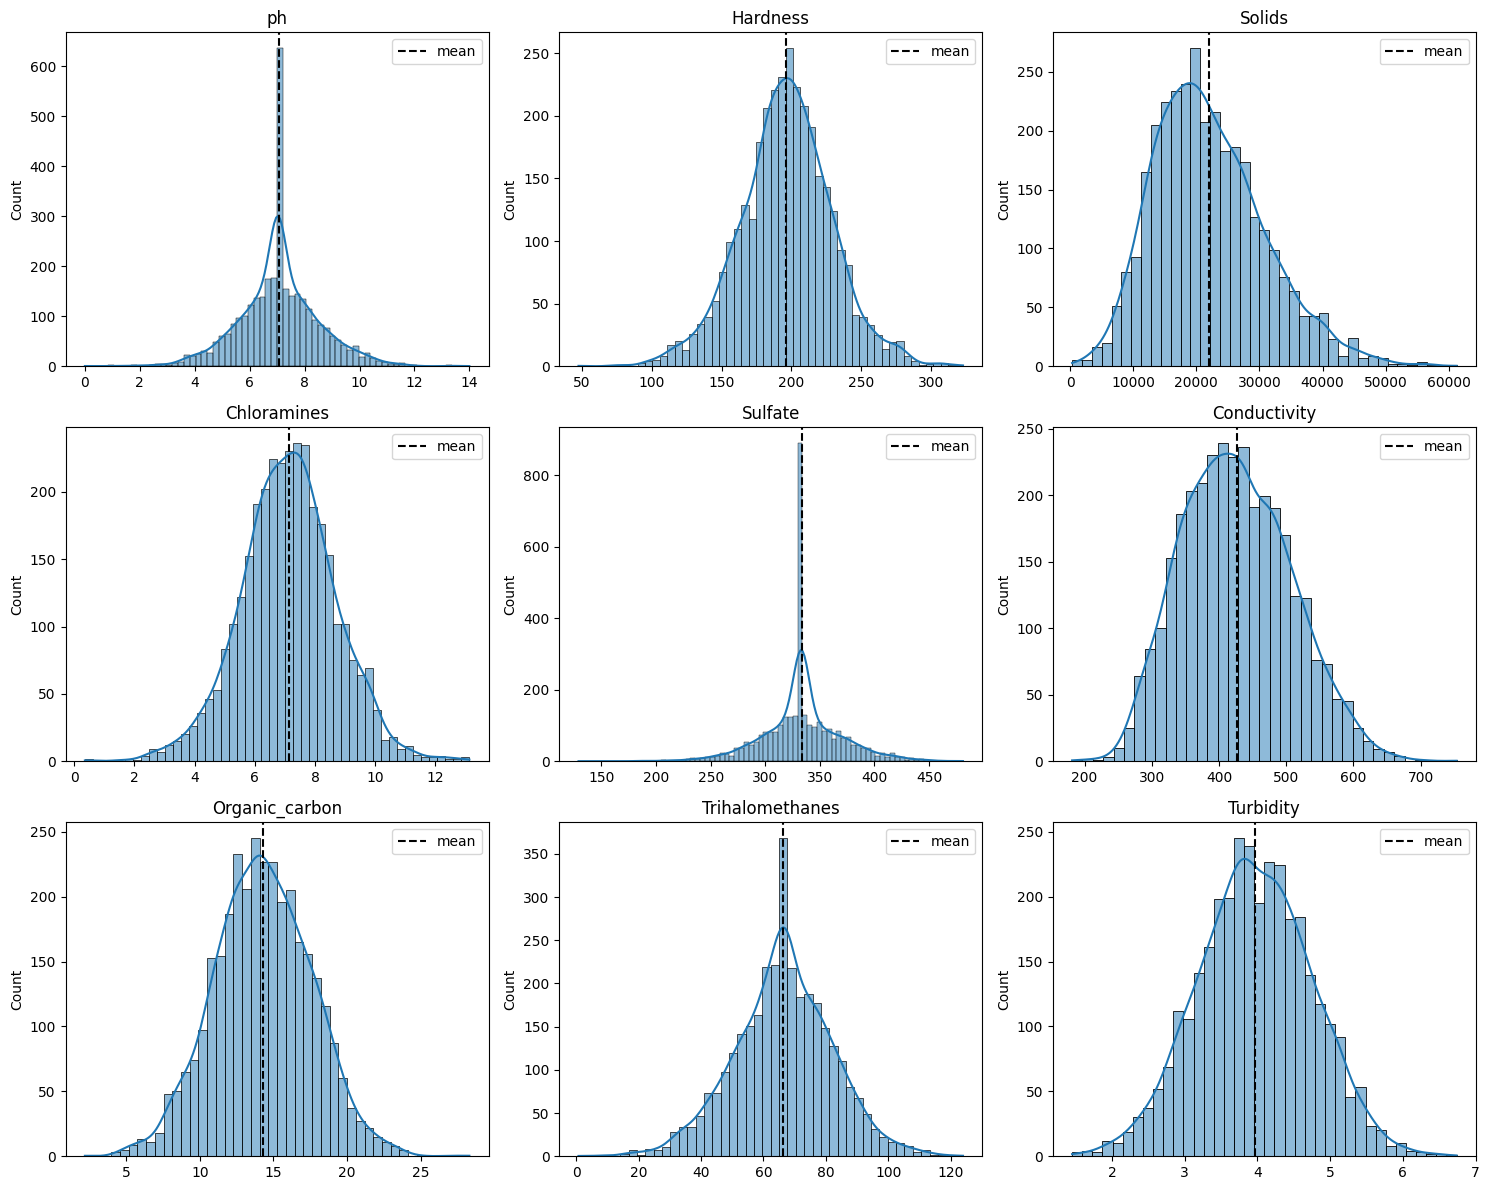

In [6]:
features = [c for c in df_clean.columns if c != 'Potability']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df_clean[col], kde=True, ax=axes[i])
    axes[i].axvline(df_clean[col].mean(), color='black', linestyle='dashed', label='mean')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend()

plt.tight_layout()
plt.show()

Each histogram shows how often each value range appears. The dashed line is the mean and the curve is a smoothed estimate of the shape (KDE). Most features are roughly bell shaped and centred near their mean. `Solids` is skewed to the right, with a long tail of high values. This fits the large gap between its mean and its maximum in `describe()`.

## 5. Class balance

Potability
0    0.61
1    0.39
Name: proportion, dtype: float64


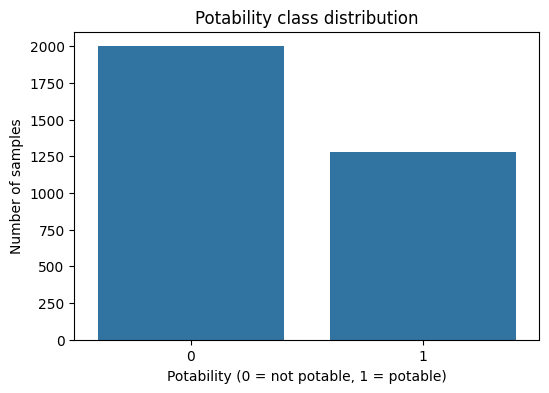

In [7]:
print(df_clean['Potability'].value_counts(normalize=True).round(3))

plt.figure(figsize=(6, 4))
sns.countplot(x='Potability', data=df_clean)
plt.title('Potability class distribution')
plt.xlabel('Potability (0 = not potable, 1 = potable)')
plt.ylabel('Number of samples')
plt.show()

About 61% of samples are not potable and 39% are potable. The classes are imbalanced. A model that always predicts "not potable" would be right about 61% of the time without learning anything. Accuracy alone would be a misleading score here.

## 6. Relationships between features

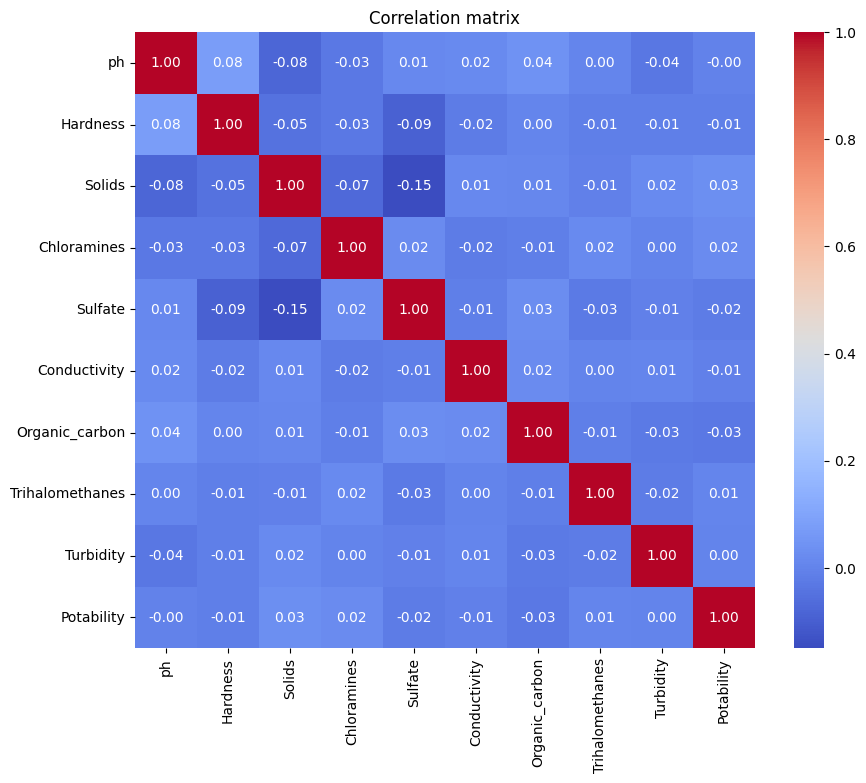

Solids             0.034
Organic_carbon    -0.030
Chloramines        0.024
Sulfate           -0.020
Hardness          -0.014
Conductivity      -0.008
Trihalomethanes    0.007
ph                -0.003
Turbidity          0.002
Name: Potability, dtype: float64


In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

# Correlation of each feature with the target, strongest first
print(df_clean.corr()['Potability'].drop('Potability').sort_values(key=abs, ascending=False).round(3))

Correlation ranges from -1 to 1. A value near 0 means no linear relationship. Here the correlations between features are all close to 0. The correlations with `Potability` are also very weak. No single feature separates safe water from unsafe water. This suggests the classification task will be hard. Correlation only measures linear relationships, so a weak value does not prove a feature is useless.

## 7. Features by potability class

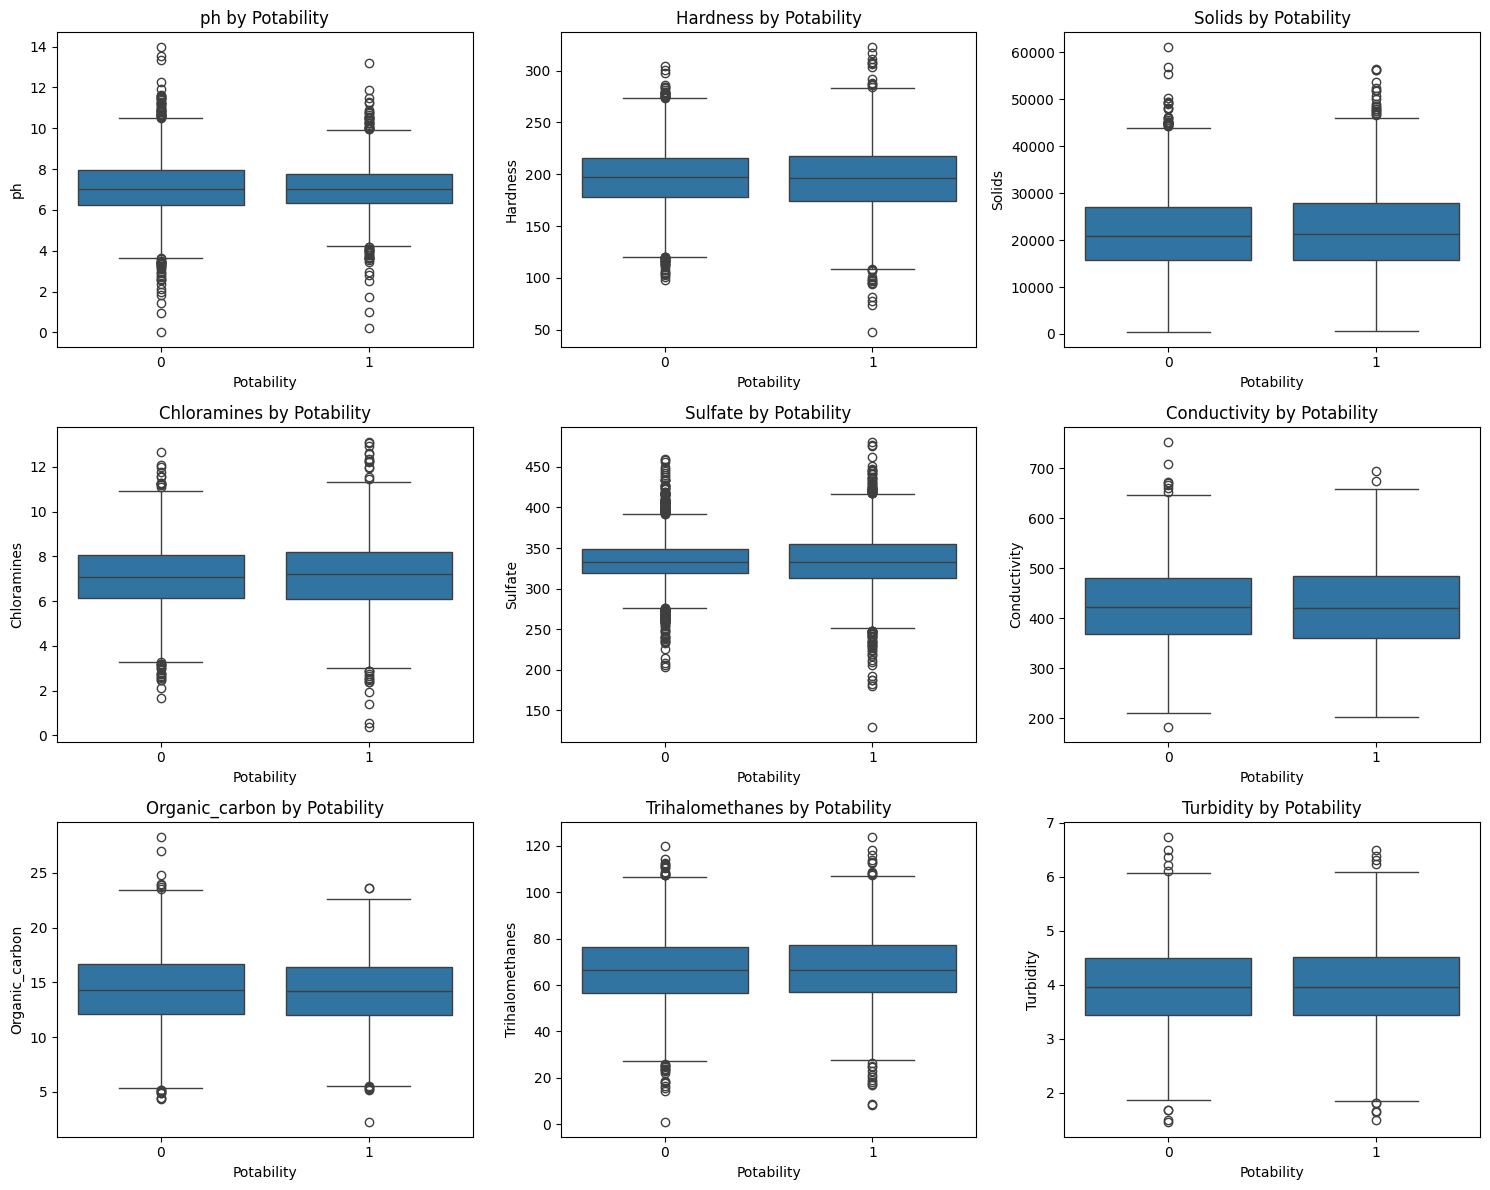

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='Potability', y=col, data=df_clean, ax=axes[i])
    axes[i].set_title(f'{col} by Potability')

plt.tight_layout()
plt.show()

A boxplot shows the median (middle line), the middle 50% of values (the box) and outliers (the dots). For every feature, the boxes for class 0 and class 1 overlap heavily and the medians are close. This matches the weak correlations. The chemical measurements alone do not clearly separate the two classes. Many features also show outliers on both sides.